In [22]:
import pandas as pd
import numpy as np



In [23]:
df=pd.read_csv("DateFruit_Dataset.csv")

In [24]:
X = df.drop('Class', axis=1)
y = df['Class']


In [25]:

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
le=LabelEncoder()
y=le.fit_transform(y)
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [27]:

# data_dataloader = DataLoader, batch_size=32, shuffle=False)
xtrain_tensor = torch.tensor(xtrain_scaled, dtype=torch.float32)
ytrain_tensor = torch.tensor(ytrain, dtype=torch.long).view(-1, 1)
xtest_tensor = torch.tensor(xtest_scaled, dtype=torch.float32)
ytest_tensor = torch.tensor(ytest, dtype=torch.long).view(-1, 1)

In [28]:
train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor)
test_dataset = TensorDataset(xtest_tensor, ytest_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
# as soft max is used by cross entropy loss, we don't need to apply softmax in the output layer of the model.

class ANNModel(nn.Module):
    def __init__(self):
        super(ANNModel, self).__init__()
        self.model=nn.Sequential(
            nn.Linear(34, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 7)  # Assuming 7 classes for classification

        )
    def forward(self, x):
        return self.model(x)
        



In [30]:
model = ANNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


<Axes: >

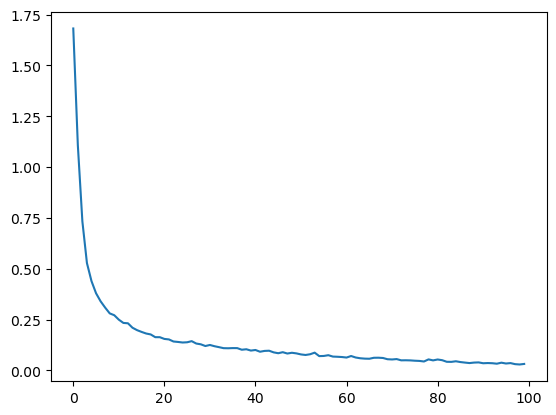

In [31]:
#training
epochs = 100
best_loss = float('inf')
training_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for xb,yb in train_loader:
        outputs = model(xb)
        loss = criterion(outputs, yb.view(-1))  # Reshape yb to match the expected shape
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()
    loss_of_epoch = running_loss / len(train_loader)
    training_losses.append(loss_of_epoch)
    if loss_of_epoch < best_loss:
        best_loss = loss_of_epoch
        torch.save(model.state_dict(), 'best_model_2.pth')
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(x=range(epochs), y=training_losses)      

In [32]:
model.load_state_dict(torch.load('best_model_2.pth'))
model.eval()
total = 0
correct = 0
with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        val, predicted = torch.max(outputs.data, 1)
        total += yb.size(0)
        correct += (predicted == yb.view(-1)).sum().item()  
print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 93.89%


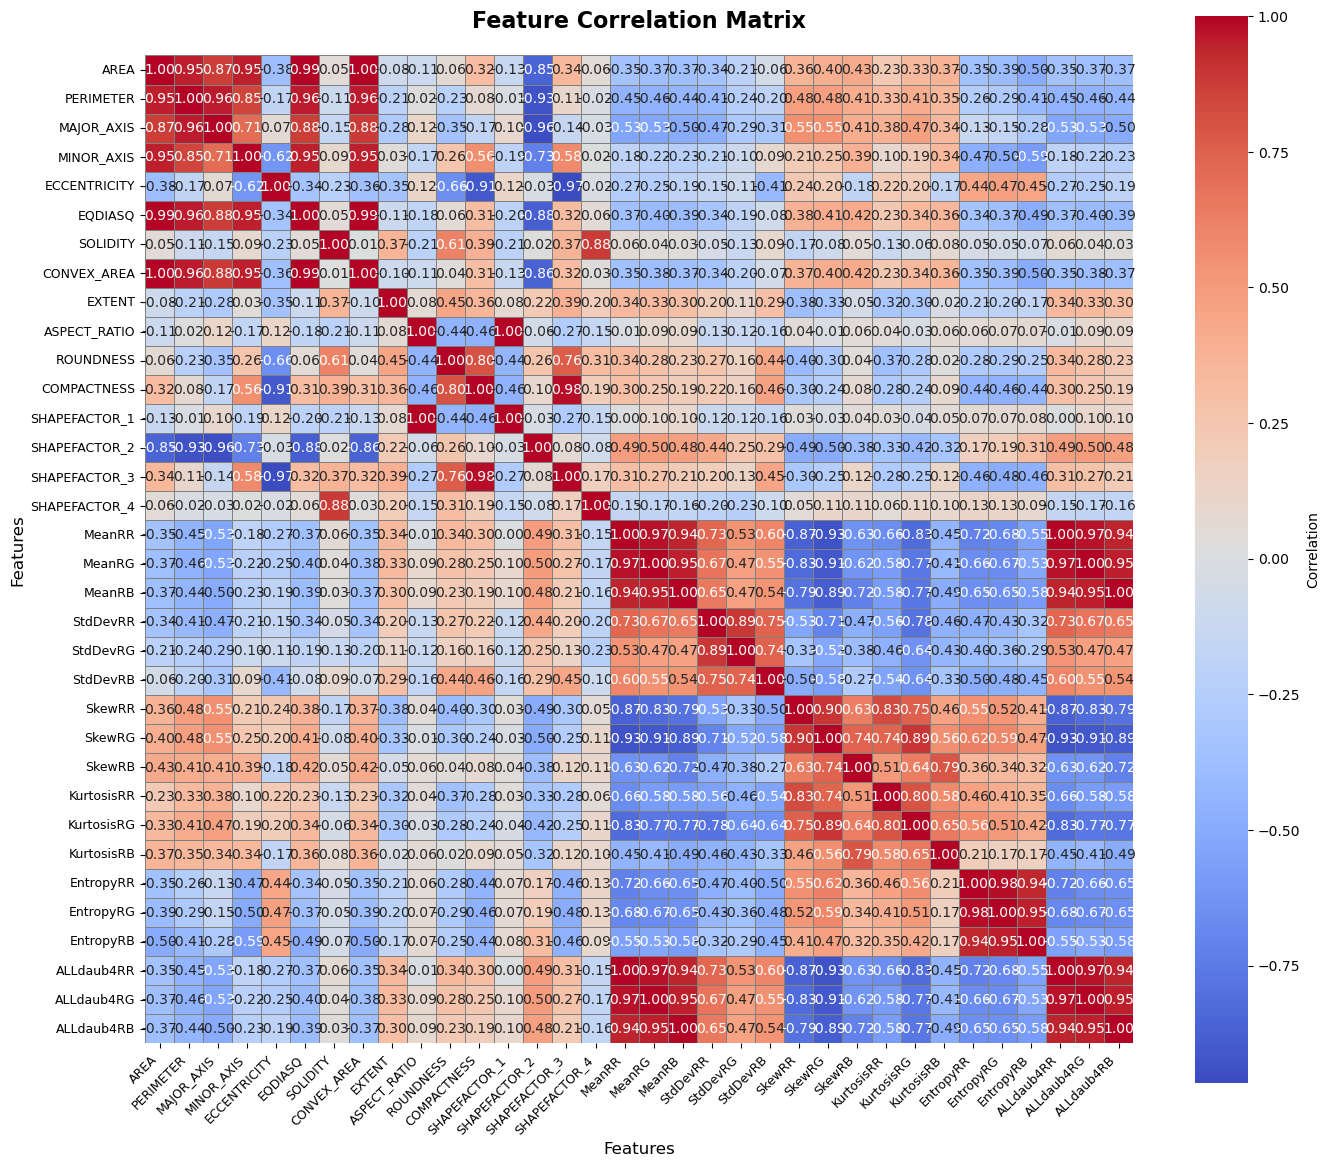

In [41]:
plt.figure(figsize=(14, 12))
sns.heatmap(xtrain.corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            cbar_kws={'label': 'Correlation'}, square=True, 
            linewidths=0.5, linecolor='gray')
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()